# Notebook 01_V3 — Modèle physique SWRO corrigé

**PFE — Master Science des Données**

## Objectif

Cette version corrige le problème identifié dans V2 : le débit de perméat était trop faible par rapport au débit d'alimentation, ce qui produisait une SEC artificiellement élevée.

La V3 utilise une approche de **dimensionnement cohérent de la surface membranaire** :

- la pression osmotique dépend de la salinité ;
- la pression nette dépend de la pression appliquée et de la pression osmotique ;
- le flux membranaire dépend de la pression nette, de la température et de l'état de membrane ;
- la surface membranaire est dimensionnée pour obtenir le taux de récupération demandé dans une plage plausible ;
- le bilan `feed = permeate + concentrate` est vérifié ;
- la puissance de pompe et la récupération ERD sont calculées ;
- la SEC est calculée avec un bruit de mesure ;
- des contrôles automatiques valident le dataset.

> **Important :** toutes les données sont synthétiques. Les coefficients sont des hypothèses de simulation et devront être présentés comme tels dans le mémoire.

In [1]:
# ============================================================
# 0. IMPORTS ET CONFIGURATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

N_SAMPLES = 10_000

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "dataset_physical_v3.csv"

BAR_TO_PA = 100_000
M3H_TO_M3S = 1 / 3600

print("Configuration chargée.")
print(f"Observations : {N_SAMPLES}")
print(f"Sortie       : {OUTPUT_FILE}")

Configuration chargée.
Observations : 10000
Sortie       : data\dataset_physical_v3.csv


## 1. Plages de fonctionnement

Ces plages sont des hypothèses de simulation.

In [2]:
RANGES = {
    "pressure_bar": (55, 70),
    "feed_flow_m3_h": (200, 1000),
    "salinity_g_L": (34, 42),
    "temperature_C": (15, 30),
    "recovery_rate": (0.30, 0.45),
    "pump_efficiency": (0.75, 0.90),
    "erd_efficiency": (0.80, 0.96),
    "membrane_condition": (0.75, 1.00),
}

for variable, (minimum, maximum) in RANGES.items():
    print(f"{variable:25s}: {minimum} → {maximum}")

pressure_bar             : 55 → 70
feed_flow_m3_h           : 200 → 1000
salinity_g_L             : 34 → 42
temperature_C            : 15 → 30
recovery_rate            : 0.3 → 0.45
pump_efficiency          : 0.75 → 0.9
erd_efficiency           : 0.8 → 0.96
membrane_condition       : 0.75 → 1.0


In [3]:
# Génération des conditions de fonctionnement

pressure_bar = np.random.uniform(*RANGES["pressure_bar"], N_SAMPLES)
feed_flow_m3_h = np.random.uniform(*RANGES["feed_flow_m3_h"], N_SAMPLES)
salinity_g_L = np.random.uniform(*RANGES["salinity_g_L"], N_SAMPLES)
temperature_C = np.random.uniform(*RANGES["temperature_C"], N_SAMPLES)
recovery_rate_target = np.random.uniform(*RANGES["recovery_rate"], N_SAMPLES)
pump_efficiency = np.random.uniform(*RANGES["pump_efficiency"], N_SAMPLES)
erd_efficiency = np.random.uniform(*RANGES["erd_efficiency"], N_SAMPLES)
membrane_condition = np.random.uniform(*RANGES["membrane_condition"], N_SAMPLES)

print("Variables générées.")

Variables générées.


## 2. Pression osmotique

Modèle simplifié :

\[
\pi = k_\pi S
\]

avec un coefficient de simulation de 0,75 bar/(g/L).

In [4]:
OSMOTIC_COEFF_BAR_PER_G_L = 0.75

osmotic_pressure_feed_bar = (
    OSMOTIC_COEFF_BAR_PER_G_L * salinity_g_L
)

concentrate_salinity_g_L = (
    salinity_g_L / (1 - recovery_rate_target)
)

osmotic_pressure_concentrate_bar = (
    OSMOTIC_COEFF_BAR_PER_G_L * concentrate_salinity_g_L
)

osmotic_pressure_avg_bar = (
    osmotic_pressure_feed_bar
    + osmotic_pressure_concentrate_bar
) / 2

print(f"Pression osmotique alimentation moyenne : "
      f"{osmotic_pressure_feed_bar.mean():.2f} bar")

print(f"Pression osmotique concentrat moyenne : "
      f"{osmotic_pressure_concentrate_bar.mean():.2f} bar")

Pression osmotique alimentation moyenne : 28.50 bar
Pression osmotique concentrat moyenne : 45.79 bar


## 3. Pression nette disponible

\[
\Delta P_{net}=P_{pump}-\pi_{avg}
\]

Une marge minimale est conservée pour éviter des situations non physiques dans la simulation.

In [5]:
net_membrane_pressure_bar = (
    pressure_bar - osmotic_pressure_avg_bar
)

net_membrane_pressure_bar = np.maximum(
    net_membrane_pressure_bar,
    5.0
)

print(f"Pression nette moyenne : "
      f"{net_membrane_pressure_bar.mean():.2f} bar")

Pression nette moyenne : 25.27 bar


## 4. Facteurs température et état de membrane

In [6]:
temperature_reference_C = 25.0

temperature_factor = (
    1 + 0.025 * (temperature_C - temperature_reference_C)
)

temperature_factor = np.clip(
    temperature_factor,
    0.75,
    1.15
)

# Condition = 1 : membrane neuve / très bonne
# Condition = 0.75 : membrane dégradée
membrane_factor = (
    0.75 + 0.25 * membrane_condition
)

print(
    f"Facteur température : "
    f"{temperature_factor.min():.3f} → "
    f"{temperature_factor.max():.3f}"
)

print(
    f"Facteur membrane : "
    f"{membrane_factor.min():.3f} → "
    f"{membrane_factor.max():.3f}"
)

Facteur température : 0.750 → 1.125
Facteur membrane : 0.938 → 1.000


## 5. Flux membranaire

On utilise un modèle simplifié :

\[
J=A\times\Delta P_{net}\times f_T\times f_M
\]

Le coefficient de perméabilité est volontairement choisi pour produire un flux dans une plage exploitable pour la simulation.

In [7]:
# Coefficient de perméabilité synthétique
A_base = 1.00

flux_permeate_L_m2_h = (
    A_base
    * net_membrane_pressure_bar
    * temperature_factor
    * membrane_factor
)

print(f"Flux moyen : {flux_permeate_L_m2_h.mean():.2f} L/m²/h")
print(f"Flux min   : {flux_permeate_L_m2_h.min():.2f} L/m²/h")
print(f"Flux max   : {flux_permeate_L_m2_h.max():.2f} L/m²/h")

Flux moyen : 22.94 L/m²/h
Flux min   : 9.25 L/m²/h
Flux max   : 40.73 L/m²/h


## 6. Dimensionnement cohérent de la surface membranaire

**Correction principale de la V2.**

Le débit de perméat cible est défini directement par :

\[
Q_p=Q_f\times R
\]

Puis la surface nécessaire est calculée à partir du flux :

\[
A_m=\frac{Q_p\times1000}{J}
\]

Ainsi, le flux et la surface restent cohérents avec le taux de récupération demandé.

Cette étape représente un **dimensionnement virtuel** du système, pas la mesure d'une installation réelle.

In [8]:
permeate_flow_target_m3_h = (
    feed_flow_m3_h * recovery_rate_target
)

membrane_area_m2 = (
    permeate_flow_target_m3_h * 1000
    / flux_permeate_L_m2_h
)

# Débit effectivement produit par la membrane
permeate_flow_m3_h = (
    flux_permeate_L_m2_h
    * membrane_area_m2
    / 1000
)

concentrate_flow_m3_h = (
    feed_flow_m3_h - permeate_flow_m3_h
)

effective_recovery_rate = (
    permeate_flow_m3_h / feed_flow_m3_h
)

print(f"Surface membranaire moyenne : {membrane_area_m2.mean():.1f} m²")
print(f"Débit perméat moyen : {permeate_flow_m3_h.mean():.2f} m³/h")
print(f"Récupération cible moyenne : "
      f"{recovery_rate_target.mean()*100:.2f} %")
print(f"Récupération effective moyenne : "
      f"{effective_recovery_rate.mean()*100:.2f} %")

Surface membranaire moyenne : 10537.1 m²
Débit perméat moyen : 225.96 m³/h
Récupération cible moyenne : 37.45 %
Récupération effective moyenne : 37.45 %


## 7. Puissance de pompe

\[
P_{hyd}=\Delta P\times Q_f
\]

\[
P_{pump}=\frac{P_{hyd}}{\eta_{pump}}
\]

In [9]:
pressure_pa = pressure_bar * BAR_TO_PA
feed_flow_m3_s = feed_flow_m3_h * M3H_TO_M3S

hydraulic_power_kW = (
    pressure_pa * feed_flow_m3_s / 1000
)

pump_power_kW = (
    hydraulic_power_kW / pump_efficiency
)

print(f"Puissance hydraulique moyenne : "
      f"{hydraulic_power_kW.mean():.2f} kW")

print(f"Puissance pompe moyenne : "
      f"{pump_power_kW.mean():.2f} kW")

Puissance hydraulique moyenne : 1046.35 kW
Puissance pompe moyenne : 1271.03 kW


## 8. Récupération d'énergie ERD

Le concentrat quitte la membrane sous pression. On estime une puissance récupérable simplifiée :

\[
P_{ERD}=P_{hyd,conc}\times\eta_{ERD}\times f_{transfert}
\]

On limite la récupération à 45 % de la puissance de pompe pour éviter un comportement irréaliste du modèle.

In [10]:
concentrate_flow_m3_s = (
    concentrate_flow_m3_h * M3H_TO_M3S
)

concentrate_hydraulic_power_kW = (
    pressure_pa * concentrate_flow_m3_s / 1000
)

ERD_TRANSFER_FACTOR = 0.80

recovered_power_kW = (
    concentrate_hydraulic_power_kW
    * erd_efficiency
    * ERD_TRANSFER_FACTOR
)

recovered_power_kW = np.minimum(
    recovered_power_kW,
    0.45 * pump_power_kW
)

net_power_kW = (
    pump_power_kW - recovered_power_kW
)

print(f"Puissance récupérée moyenne : "
      f"{recovered_power_kW.mean():.2f} kW")

print(f"Puissance nette moyenne : "
      f"{net_power_kW.mean():.2f} kW")

Puissance récupérée moyenne : 460.83 kW
Puissance nette moyenne : 810.20 kW


## 9. SEC

\[
SEC=\frac{P_{net}}{Q_p}
\]

Unité : kWh/m³.

In [11]:
SEC_physical = (
    net_power_kW / permeate_flow_m3_h
)

print(f"SEC moyenne : {SEC_physical.mean():.3f} kWh/m³")
print(f"SEC médiane : {np.median(SEC_physical):.3f} kWh/m³")
print(f"SEC min : {SEC_physical.min():.3f} kWh/m³")
print(f"SEC max : {SEC_physical.max():.3f} kWh/m³")

SEC moyenne : 3.618 kWh/m³
SEC médiane : 3.568 kWh/m³
SEC min : 2.410 kWh/m³
SEC max : 5.427 kWh/m³


## 10. Bruit de mesure

Le bruit simule les variations non modélisées et les erreurs de mesure.

In [12]:
noise = np.random.normal(0, 0.03, N_SAMPLES)

SEC_observed = np.maximum(
    SEC_physical * (1 + noise),
    0.1
)

## 11. Construction du dataset V3

In [13]:
df = pd.DataFrame({
    "pressure_bar": pressure_bar,
    "feed_flow_m3_h": feed_flow_m3_h,
    "salinity_g_L": salinity_g_L,
    "temperature_C": temperature_C,

    "recovery_rate_target": recovery_rate_target,
    "effective_recovery_rate": effective_recovery_rate,

    "pump_efficiency": pump_efficiency,
    "erd_efficiency": erd_efficiency,
    "membrane_condition": membrane_condition,

    "osmotic_pressure_feed_bar": osmotic_pressure_feed_bar,
    "osmotic_pressure_concentrate_bar": osmotic_pressure_concentrate_bar,
    "osmotic_pressure_avg_bar": osmotic_pressure_avg_bar,
    "net_membrane_pressure_bar": net_membrane_pressure_bar,

    "temperature_factor": temperature_factor,
    "membrane_factor": membrane_factor,

    "flux_permeate_L_m2_h": flux_permeate_L_m2_h,
    "membrane_area_m2": membrane_area_m2,

    "permeate_flow_m3_h": permeate_flow_m3_h,
    "concentrate_flow_m3_h": concentrate_flow_m3_h,

    "hydraulic_power_kW": hydraulic_power_kW,
    "pump_power_kW": pump_power_kW,
    "recovered_power_kW": recovered_power_kW,
    "net_power_kW": net_power_kW,

    "SEC_physical_kWh_m3": SEC_physical,
    "SEC_kWh_m3": SEC_observed,
})

df.head()

,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,effective_recovery_rate,pump_efficiency,erd_efficiency,membrane_condition,osmotic_pressure_feed_bar,...,flux_permeate_L_m2_h,membrane_area_m2,permeate_flow_m3_h,concentrate_flow_m3_h,hydraulic_power_kW,pump_power_kW,recovered_power_kW,net_power_kW,SEC_physical_kWh_m3,SEC_kWh_m3
0,60.618102,498.912655,39.839986,24.572169,0.344837,0.344837,0.877085,0.918649,0.760665,29.879990,...,21.275939,8086.291607,172.043446,326.869208,840.087169,957.816749,404.495186,553.321563,3.216173,3.184662
1,69.260715,466.329677,35.476096,21.889387,0.314223,0.314223,0.824178,0.940976,0.957126,26.607072,...,33.353656,4393.262114,146.531354,319.798323,897.175741,1088.570944,463.158161,625.412783,4.268116,4.305624
2,65.979909,340.923130,36.773118,29.467478,0.318954,0.318954,0.779320,0.874109,0.812327,27.579838,...,33.843298,3213.007111,108.738756,232.184374,624.835476,801.770265,297.575841,504.194424,4.636750,4.605504
3,63.979877,685.813336,39.306245,18.284677,0.327101,0.327101,0.860496,0.846269,0.820984,29.479684,...,21.727996,10324.467854,224.330001,461.483335,1218.840363,1416.438872,555.258399,861.180472,3.838900,3.889449
4,57.340280,581.299328,37.856715,23.817846,0.330548,0.330548,0.812802,0.851015,0.806561,28.392536,...,20.260279,9483.942996,192.147330,389.151998,925.885167,1139.127962,421.991791,717.136171,3.732220,3.690048


## 12. Contrôles automatiques

Le notebook doit vérifier les contraintes avant de sauvegarder les données.

In [14]:
print("Shape :", df.shape)
print("Valeurs manquantes :", df.isnull().sum().sum())
print("Doublons :", df.duplicated().sum())

flow_error = (
    df["feed_flow_m3_h"]
    - df["permeate_flow_m3_h"]
    - df["concentrate_flow_m3_h"]
)

recovery_error = (
    df["effective_recovery_rate"]
    - df["recovery_rate_target"]
)

checks = {
    "Pression positive":
        (df["pressure_bar"] > 0).all(),

    "Débit alimentation positif":
        (df["feed_flow_m3_h"] > 0).all(),

    "Perméat positif":
        (df["permeate_flow_m3_h"] > 0).all(),

    "Concentrat positif":
        (df["concentrate_flow_m3_h"] >= 0).all(),

    "Récupération dans la plage cible":
        df["recovery_rate_target"].between(0.30, 0.45).all(),

    "Récupération effective dans la plage":
        df["effective_recovery_rate"].between(0.30, 0.45).all(),

    "Erreur bilan débit < 1e-9":
        np.abs(flow_error).max() < 1e-9,

    "Erreur récupération < 1e-9":
        np.abs(recovery_error).max() < 1e-9,

    "SEC positive":
        (df["SEC_kWh_m3"] > 0).all(),

    "Rendement pompe valide":
        df["pump_efficiency"].between(0, 1).all(),

    "Rendement ERD valide":
        df["erd_efficiency"].between(0, 1).all(),
}

for name, ok in checks.items():
    print(f"{name:45s}: {'OK' if ok else 'ERREUR'}")

assert all(checks.values()), "Au moins un contrôle physique a échoué."

print("\nTous les contrôles physiques sont validés.")

Shape : (10000, 25)
Valeurs manquantes : 0
Doublons : 0
Pression positive                            : OK
Débit alimentation positif                   : OK
Perméat positif                              : OK
Concentrat positif                           : OK
Récupération dans la plage cible             : OK
Récupération effective dans la plage         : OK
Erreur bilan débit < 1e-9                    : OK
Erreur récupération < 1e-9                   : OK
SEC positive                                 : OK
Rendement pompe valide                       : OK
Rendement ERD valide                         : OK

Tous les contrôles physiques sont validés.


## 13. Statistiques descriptives

In [15]:
pd.set_option("display.max_columns", None)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pressure_bar,10000.0,62.412393,4.314452,55.000175,58.694933,62.387929,66.100095,69.995765
feed_flow_m3_h,10000.0,603.623901,231.435641,200.126196,403.156641,604.717421,805.183377,999.939861
salinity_g_L,10000.0,38.000403,2.294190,34.000385,36.029983,38.016545,39.957391,41.999208
temperature_C,10000.0,22.480701,4.334919,15.000083,18.702859,22.500454,26.206744,29.996841
recovery_rate_target,10000.0,0.374530,0.043393,0.300003,0.336641,0.374058,0.412572,0.449996
effective_recovery_rate,10000.0,0.374530,0.043393,0.300003,0.336641,0.374058,0.412572,0.449996
pump_efficiency,10000.0,0.825472,0.043251,0.750001,0.788543,0.825914,0.863017,0.899991
erd_efficiency,10000.0,0.880286,0.046025,0.800043,0.840622,0.880674,0.920395,0.959950
membrane_condition,10000.0,0.874806,0.071492,0.750033,0.813000,0.874808,0.936956,0.999969
osmotic_pressure_feed_bar,10000.0,28.500302,1.720643,25.500289,27.022487,28.512409,29.968043,31.499406


## 14. Distribution de la SEC

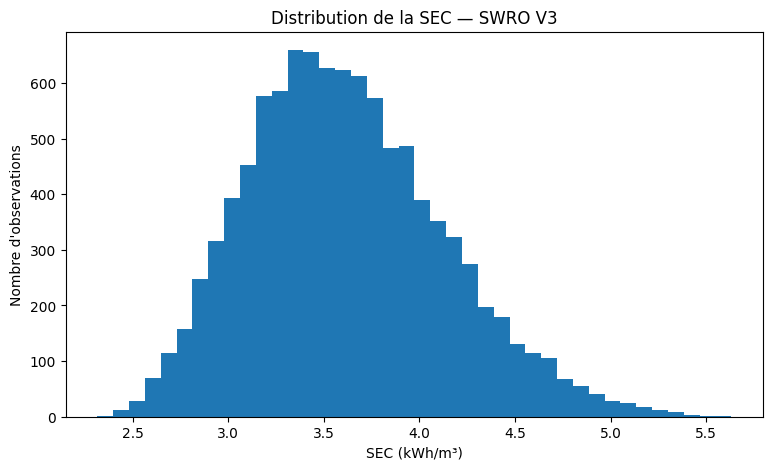

In [16]:
plt.figure(figsize=(9, 5))
plt.hist(df["SEC_kWh_m3"], bins=40)
plt.xlabel("SEC (kWh/m³)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la SEC — SWRO V3")
plt.show()

## 15. Relations physiques avec la SEC

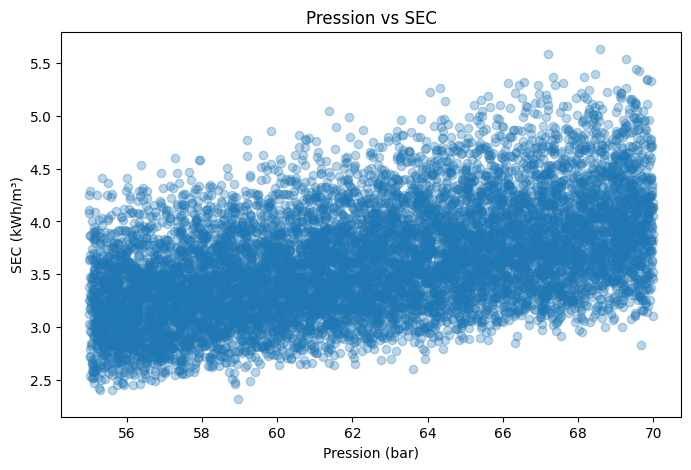

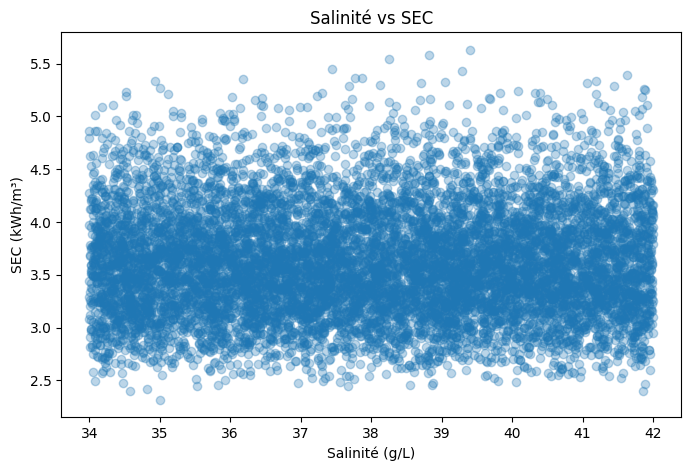

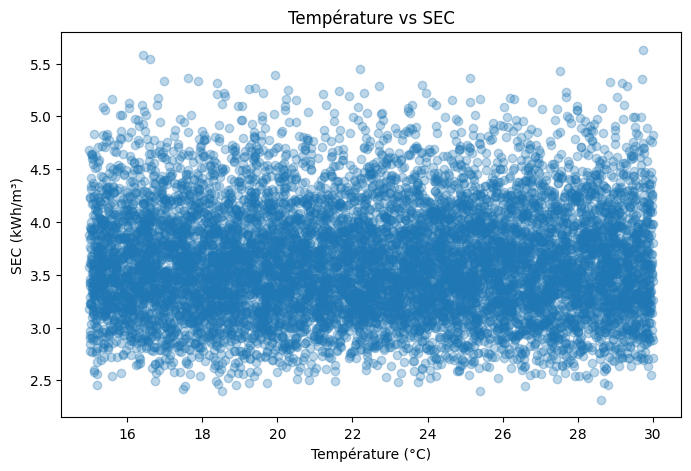

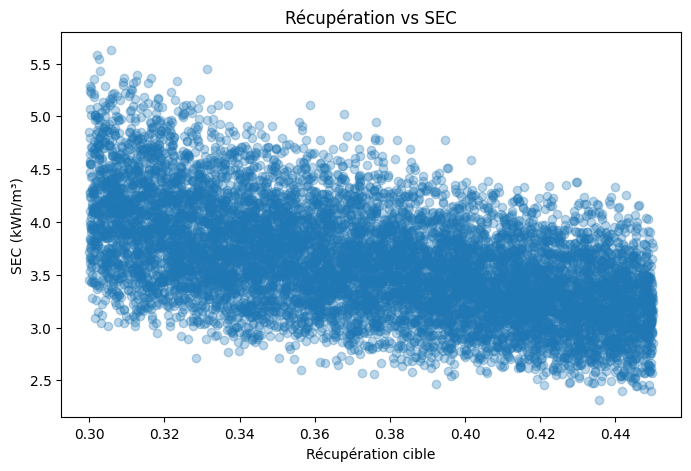

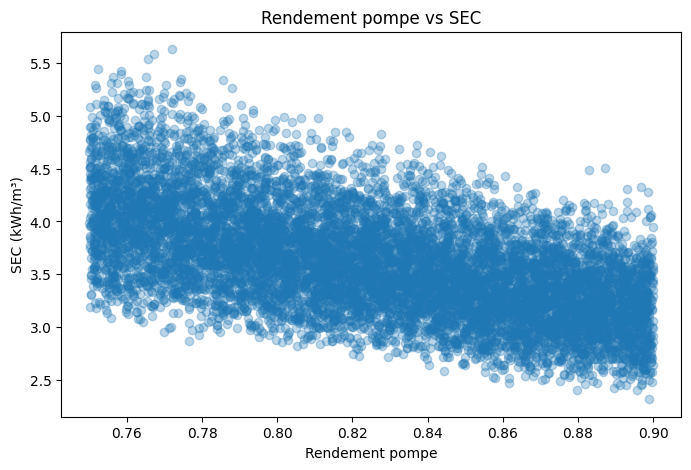

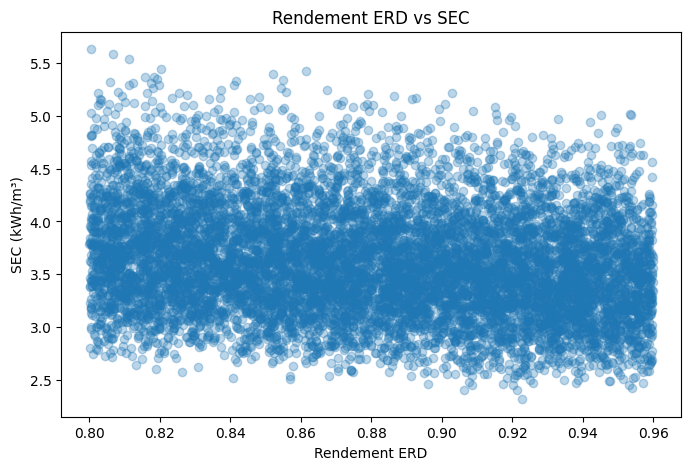

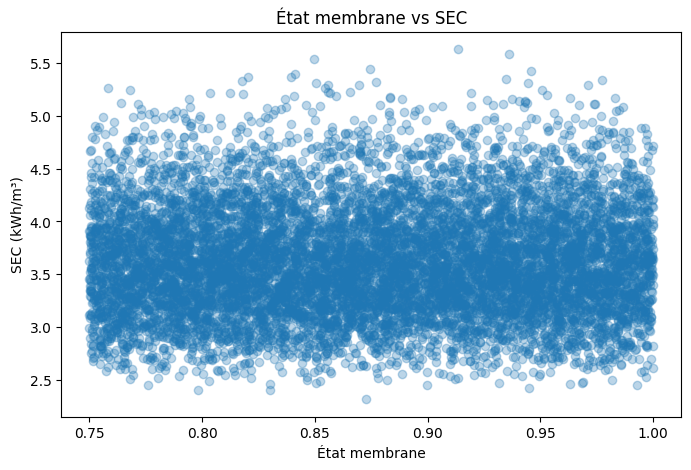

In [17]:
plots = [
    ("pressure_bar", "Pression (bar)", "Pression vs SEC"),
    ("salinity_g_L", "Salinité (g/L)", "Salinité vs SEC"),
    ("temperature_C", "Température (°C)", "Température vs SEC"),
    ("recovery_rate_target", "Récupération cible", "Récupération vs SEC"),
    ("pump_efficiency", "Rendement pompe", "Rendement pompe vs SEC"),
    ("erd_efficiency", "Rendement ERD", "Rendement ERD vs SEC"),
    ("membrane_condition", "État membrane", "État membrane vs SEC"),
]

for variable, xlabel, title in plots:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[variable], df["SEC_kWh_m3"], alpha=0.30)
    plt.xlabel(xlabel)
    plt.ylabel("SEC (kWh/m³)")
    plt.title(title)
    plt.show()

## 16. Corrélations avec la cible

In [18]:
correlations = (
    df.corr(numeric_only=True)["SEC_kWh_m3"]
    .sort_values(ascending=False)
)

correlations

SEC_kWh_m3                          1.000000
SEC_physical_kWh_m3                 0.977173
net_membrane_pressure_bar           0.592236
flux_permeate_L_m2_h                0.509472
pressure_bar                        0.504604
net_power_kW                        0.172400
pump_power_kW                       0.170149
recovered_power_kW                  0.156597
concentrate_flow_m3_h               0.099928
hydraulic_power_kW                  0.091613
membrane_factor                     0.014808
membrane_condition                  0.014808
salinity_g_L                        0.004545
osmotic_pressure_feed_bar           0.004545
feed_flow_m3_h                      0.002483
temperature_factor                 -0.002722
temperature_C                      -0.002722
permeate_flow_m3_h                 -0.156034
erd_efficiency                     -0.206553
osmotic_pressure_avg_bar           -0.316176
membrane_area_m2                   -0.371008
osmotic_pressure_concentrate_bar   -0.413763
effective_

## 17. Vérification du bilan de débit

In [19]:
print(
    "Erreur maximale du bilan de débit :",
    np.abs(flow_error).max(),
    "m³/h"
)

print(
    "Erreur maximale sur la récupération :",
    np.abs(recovery_error).max()
)

Erreur maximale du bilan de débit : 0.0 m³/h
Erreur maximale sur la récupération : 1.6653345369377348e-16


## 18. Sauvegarde

Le dataset final sera enregistré dans :

`data/dataset_physical_v3.csv`

In [20]:
df.to_csv(OUTPUT_FILE, index=False)

print("=" * 60)
print("DATASET SWRO — VERSION 3")
print("=" * 60)
print(f"Fichier      : {OUTPUT_FILE}")
print(f"Observations : {len(df)}")
print(f"Variables    : {len(df.columns)}")
print(f"SEC moyenne  : {df['SEC_kWh_m3'].mean():.3f} kWh/m³")
print(f"SEC médiane  : {df['SEC_kWh_m3'].median():.3f} kWh/m³")
print(f"SEC min      : {df['SEC_kWh_m3'].min():.3f} kWh/m³")
print(f"SEC max      : {df['SEC_kWh_m3'].max():.3f} kWh/m³")
print("=" * 60)

DATASET SWRO — VERSION 3
Fichier      : data\dataset_physical_v3.csv
Observations : 10000
Variables    : 25
SEC moyenne  : 3.618 kWh/m³
SEC médiane  : 3.574 kWh/m³
SEC min      : 2.316 kWh/m³
SEC max      : 5.631 kWh/m³


# Validation finale

Avant de passer au Notebook 02, vérifier dans les résultats :

- récupération cible ≈ récupération effective ;
- bilan débit exact ;
- SEC positive ;
- SEC dans un ordre de grandeur plausible ;
- pression, salinité, température, récupération et rendements ont des relations interprétables avec la SEC.

**Ne pas modifier manuellement les résultats pour obtenir une SEC souhaitée.** Si les résultats sont incohérents, on corrige le modèle physique.